In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from matplotlib import pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('./dataset/dataset.csv')

In [15]:
df = df.drop(columns=['id', 'City', 'Work Pressure', 'Job Satisfaction'])

In [16]:
for col in ['Degree', 'Profession']:
    counts = df[col].value_counts()
    df[col] = df[col].where(df[col].isin(counts[counts >= 10].index), other=pd.NA)

In [17]:
print(df.head())

   Gender   Age Profession  Academic Pressure  CGPA  Study Satisfaction  \
0    Male  33.0    Student                5.0  8.97                 2.0   
1  Female  24.0    Student                2.0  5.90                 5.0   
2    Male  31.0    Student                3.0  7.03                 5.0   
3  Female  28.0    Student                3.0  5.59                 2.0   
4  Female  25.0    Student                4.0  8.13                 3.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8 hours       Moderate      BCA   
4          5-6 hours       Moderate   M.Tech   

  Have you ever had suicidal thoughts ?  Work/Study Hours  Financial Stress  \
0                                   Yes               3.0               1.0   
1                                    No               3.0               2.0   
2                      

In [18]:
df = df.dropna()
df = df.drop_duplicates()

In [19]:
X = df.drop(columns=['Depression'])
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 22293 | Test: 5574


In [20]:
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (22293, 43) | X_test: (5574, 43)


In [21]:
all_cols = numerical_cols + preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train

cleaned_df = pd.DataFrame(X_train_dense, columns=all_cols)
cleaned_df['Depression'] = y_train.values

cleaned_df.to_csv('./dataset/cleaned_dataset.csv', index=False)

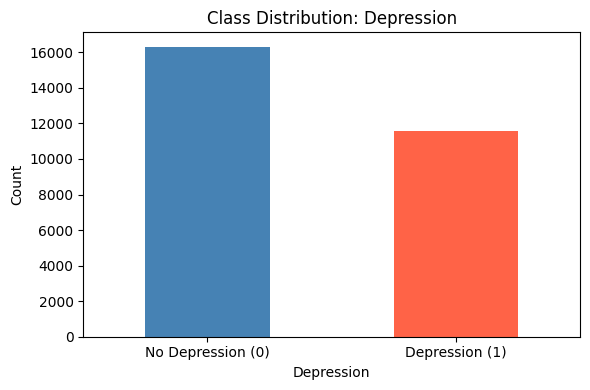

In [ ]:
plt.figure(figsize=(6, 4))
df['Depression'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution: Depression')
plt.xticks([0, 1], ['No Depression (0)', 'Depression (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

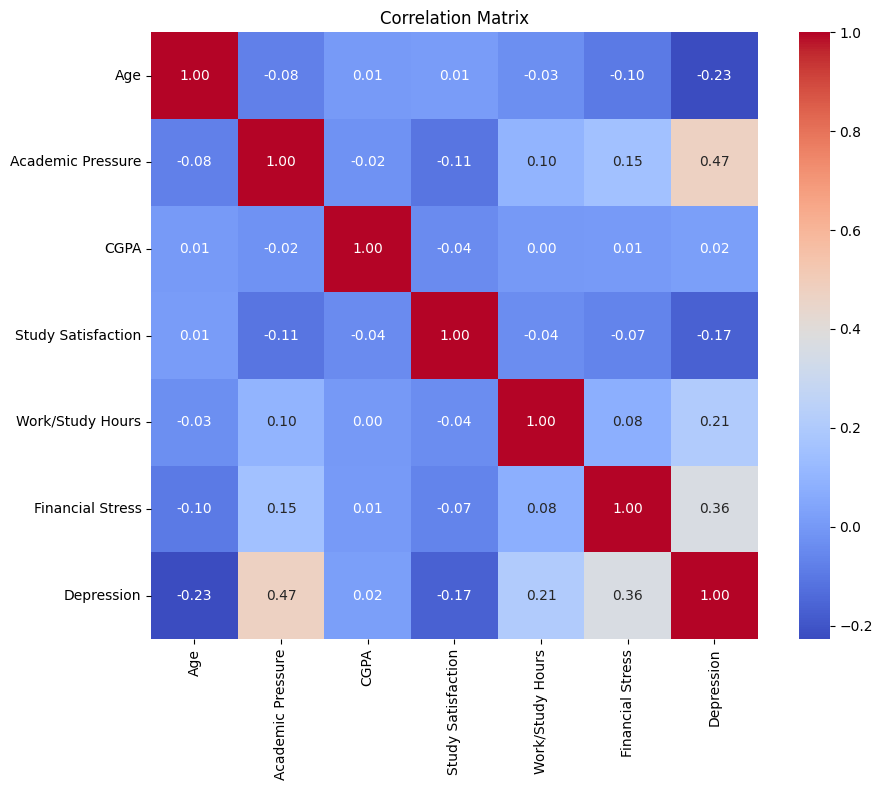

In [ ]:
plt.figure(figsize=(10, 8))
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()